# Exploratory Time-Series Analysis

**FirmScape:** How industry concentration and firm growth shape housing trajectories across U.S. **metros** (CBSA), and whether we can identify **leading indicators** of urban economic growth.

- **Unit of analysis:** Metro (CBSA)
- **Quarter-based:** 
- **Question:** How does industry concentration and firm growth patterns shape housing market trajectories across U.S. metropolitan areas, and can we identify leading indicators of urban economic growth from these relationships?


*Data: `firmscape_integrated_cbsa_quarterly.csv` (CBSA-quarter panel)*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

DATA_DIR = Path("..") / "data"
QFILE = DATA_DIR / "firmscape_integrated_cbsa_quarterly.csv"

In [2]:
# Load quarterly panel (metro = CBSA, quarter)
df = pd.read_csv(QFILE)
df["yq"] = pd.to_datetime(df["yq"].astype(str).str.replace("Q", "-") + "-01", format="%Y-%m-%d", errors="coerce")
# Restrict to rows with housing + firm data for analysis
df_analysis = df.dropna(subset=["fhfa_index", "firms_founded_yoy"], how="any").copy()
df_analysis["year"] = df_analysis["year"].astype(int)

# Comparative case metros (rise/decline and tech hubs)
CASE_METROS = {
    "Detroit (MSAD)": 19804,           # Detroit-Dearborn-Livonia — manufacturing decline
    "San Francisco (MSAD)": 41884,     # Bay Area tech hub
    "Austin": 12420,                   # Austin-Round Rock-San Marcos — tech growth
    "Seattle (MSAD)": 42644,           # Seattle-Bellevue-Kent — tech hub
}

print("Shape:", df.shape)
print("Analysis subset (non-null fhfa + firms_founded_yoy):", df_analysis.shape)
df_analysis.head()

Shape: (83230, 44)
Analysis subset (non-null fhfa + firms_founded_yoy): (19177, 44)


,cbsa_code,metro_name,city_state,year,quarter,fhfa_index,zillow_price_q,fhfa_qoq,fhfa_yoy,zillow_qoq,...,entry_emp_yoy,entry_emp_firm_count,entry_emp_mean,entry_emp_median,entry_emp_nonmissing,entry_emp_coverage,entry_emp_yoy_lag1q,entry_emp_yoy_lag2q,entry_emp_yoy_lag4q,entry_emp_yoy_lag8q
45,10180,"Abilene, TX","Abilene, TX",1986,2,108.06,NaN,NaN,NaN,NaN,...,-0.922292,2.0,238.0,238.0,2.0,1.0,-0.922292,NaN,NaN,7.738231
46,10180,"Abilene, TX","Abilene, TX",1986,3,108.28,NaN,0.002036,NaN,NaN,...,-0.922292,2.0,238.0,238.0,2.0,1.0,-0.922292,-0.922292,NaN,7.738231
47,10180,"Abilene, TX","Abilene, TX",1986,4,94.80,NaN,-0.124492,NaN,NaN,...,-0.922292,2.0,238.0,238.0,2.0,1.0,-0.922292,-0.922292,NaN,7.738231
48,10180,"Abilene, TX","Abilene, TX",1987,1,101.63,NaN,0.072046,NaN,NaN,...,-0.736345,1.0,125.5,125.5,1.0,1.0,-0.922292,-0.922292,-0.922292,NaN
49,10180,"Abilene, TX","Abilene, TX",1987,2,100.89,NaN,-0.007281,-0.066352,NaN,...,-0.736345,1.0,125.5,125.5,1.0,1.0,-0.736345,-0.922292,-0.922292,NaN


## Industry growth alongside housing price trends

Plot aggregate (US) or selected metros: firm formation growth (`firms_founded_yoy`) and housing YoY (`fhfa_yoy`, `zillow_yoy`) over time.

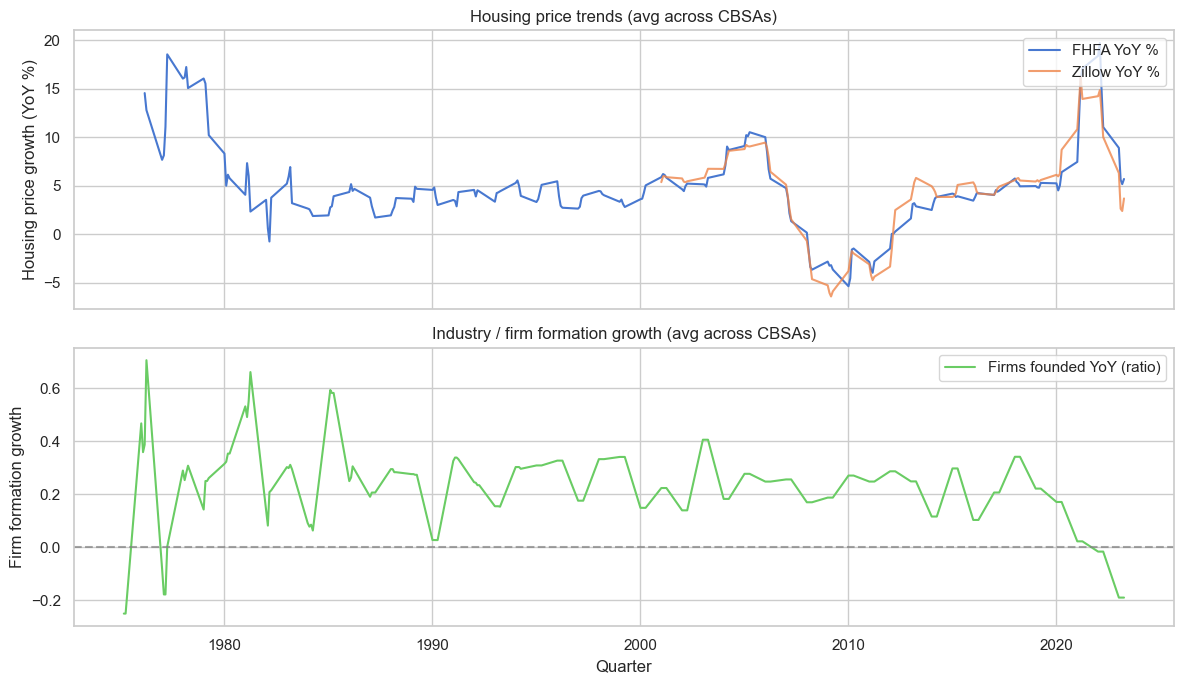

In [3]:
# National-level (average across CBSAs) quarterly series
agg = df_analysis.groupby("yq").agg(
    fhfa_yoy=("fhfa_yoy", "mean"),
    zillow_yoy=("zillow_yoy", "mean"),
    firms_founded_yoy=("firms_founded_yoy", "mean"),
    industry_count_new=("industry_count_new", "mean"),
).reset_index()

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
ax1, ax2 = axes
ax1.plot(agg["yq"], agg["fhfa_yoy"] * 100, label="FHFA YoY %", color="C0")
ax1.plot(agg["yq"], agg["zillow_yoy"] * 100, label="Zillow YoY %", color="C1", alpha=0.8)
ax1.set_ylabel("Housing price growth (YoY %)")
ax1.legend(loc="upper right")
ax1.set_title("Housing price trends (avg across CBSAs)")
ax2.plot(agg["yq"], agg["firms_founded_yoy"], label="Firms founded YoY (ratio)", color="C2")
ax2.axhline(0, color="gray", linestyle="--", alpha=0.7)
ax2.set_ylabel("Firm formation growth")
ax2.set_xlabel("Quarter")
ax2.legend(loc="upper right")
ax2.set_title("Industry / firm formation growth (avg across CBSAs)")
plt.tight_layout()
plt.show()

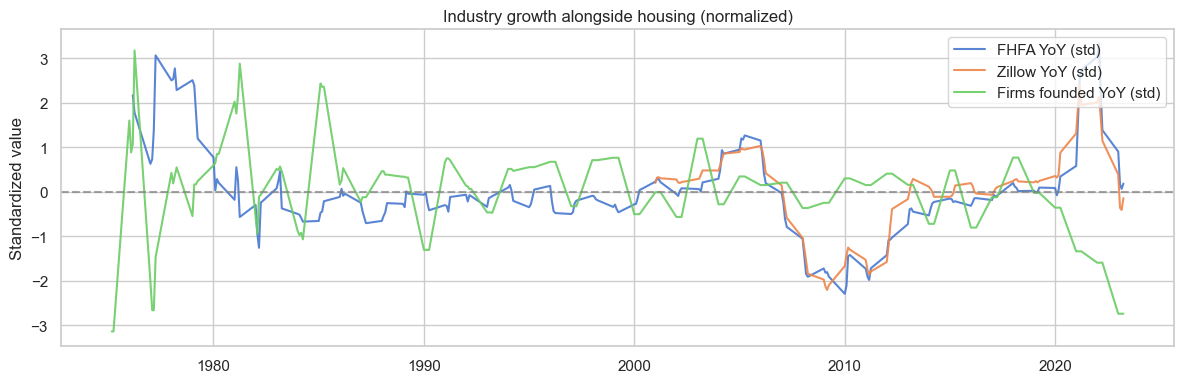

In [4]:
# Overlay: housing and firm growth on same scale (normalized for visibility)
agg_norm = agg.copy()
for c in ["fhfa_yoy", "zillow_yoy", "firms_founded_yoy"]:
    s = agg_norm[c].dropna()
    if s.abs().max() > 0:
        agg_norm[c + "_n"] = (s - s.mean()) / (s.std() + 1e-8)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(agg_norm["yq"], agg_norm["fhfa_yoy_n"], label="FHFA YoY (std)", alpha=0.9)
ax.plot(agg_norm["yq"], agg_norm["zillow_yoy_n"], label="Zillow YoY (std)", alpha=0.9)
ax.plot(agg_norm["yq"], agg_norm["firms_founded_yoy_n"], label="Firms founded YoY (std)", alpha=0.9)
ax.axhline(0, color="gray", linestyle="--", alpha=0.7)
ax.legend(loc="upper right")
ax.set_ylabel("Standardized value")
ax.set_title("Industry growth alongside housing (normalized)")
plt.tight_layout()
plt.show()

## Correlations and lagged relationships

Correlation matrix: housing growth (FHFA YoY, Zillow YoY) vs firm growth and **concentration** (HHI, industry diversity). Include lags to look for **leading indicators** (e.g. firm growth at t−k vs housing at t).

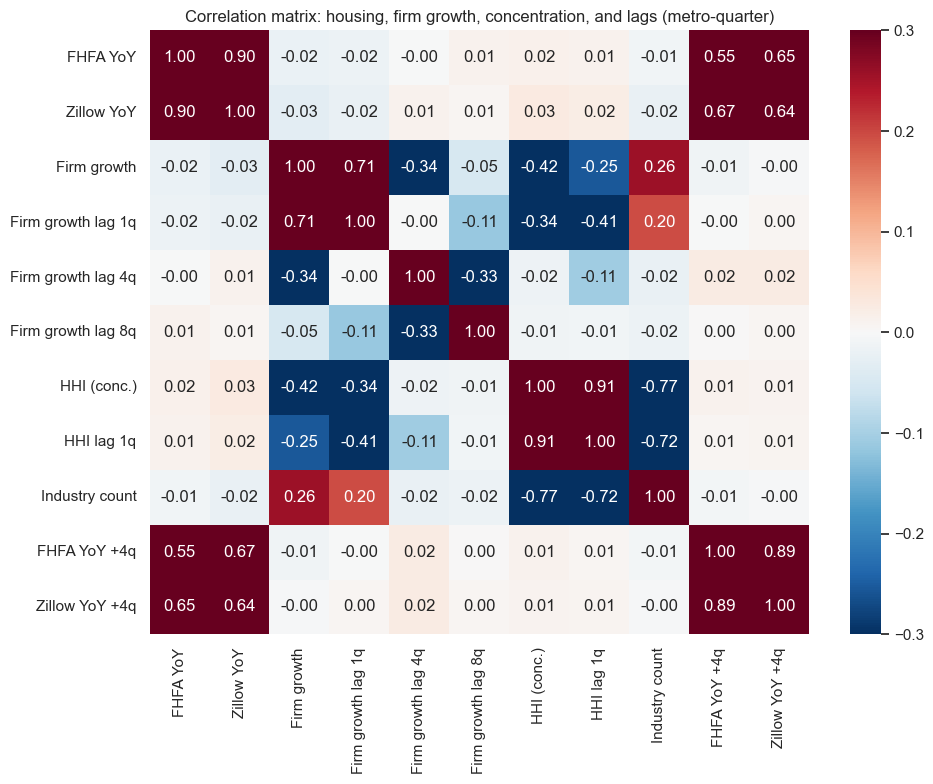

In [39]:
# Variables for correlation (housing, firm growth, concentration/diversity, lags)
corr_cols = [
    "fhfa_yoy", "zillow_yoy",
    "firms_founded_yoy", "firms_founded_yoy_lag1q", "firms_founded_yoy_lag4q", "firms_founded_yoy_lag8q",
    "hhi_new", "hhi_new_lag1q", "industry_count_new",
    "fhfa_yoy_fwd4q", "zillow_yoy_fwd4q",
]
available = [c for c in corr_cols if c in df_analysis.columns]
corr_df = df_analysis[available].dropna(how="all")

# Short labels for plot
labels = {
    "fhfa_yoy": "FHFA YoY",
    "zillow_yoy": "Zillow YoY",
    "firms_founded_yoy": "Firm growth",
    "firms_founded_yoy_lag1q": "Firm growth lag 1q",
    "firms_founded_yoy_lag4q": "Firm growth lag 4q",
    "firms_founded_yoy_lag8q": "Firm growth lag 8q",
    "hhi_new": "HHI (conc.)",
    "hhi_new_lag1q": "HHI lag 1q",
    "industry_count_new": "Industry count",
    "fhfa_yoy_fwd4q": "FHFA YoY +4q",
    "zillow_yoy_fwd4q": "Zillow YoY +4q",
}
corr = corr_df[available].corr()
corr = corr.rename(index=labels, columns=labels)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", center=0, cmap="RdBu_r", ax=ax, vmin=-0.3, vmax=0.3)
ax.set_title("Correlation matrix: housing, firm growth, concentration, and lags (metro-quarter)")
plt.tight_layout()
plt.show()

In [40]:
# Leading indicator check: does firm growth (or HHI) at t-k predict housing at t?
# Correlation of lagged firm growth with current and forward housing
lead_summary = []
for lag in ["firms_founded_yoy", "firms_founded_yoy_lag1q", "firms_founded_yoy_lag4q", "firms_founded_yoy_lag8q"]:
    if lag not in df_analysis.columns:
        continue
    for target in ["fhfa_yoy", "fhfa_yoy_fwd4q"]:
        if target not in df_analysis.columns:
            continue
        r = df_analysis[[lag, target]].corr().iloc[0, 1]
        lead_summary.append({"predictor": lag, "target": target, "correlation": r})
pd.DataFrame(lead_summary)

,predictor,target,correlation
0,firms_founded_yoy,fhfa_yoy,-0.020454
1,firms_founded_yoy,fhfa_yoy_fwd4q,-0.012790
2,firms_founded_yoy_lag1q,fhfa_yoy,-0.017498
3,firms_founded_yoy_lag1q,fhfa_yoy_fwd4q,-0.002327
4,firms_founded_yoy_lag4q,fhfa_yoy,-0.000401
5,firms_founded_yoy_lag4q,fhfa_yoy_fwd4q,0.024478
6,firms_founded_yoy_lag8q,fhfa_yoy,0.013315
7,firms_founded_yoy_lag8q,fhfa_yoy_fwd4q,0.001190


## Firm entry and housing: where we see alignment

**Integrated panel:** Lagged firm growth shows *positive* correlation with housing: e.g. `firms_founded_yoy_lag4q` vs `fhfa_yoy_fwd4q` (firm growth 4 quarters ago vs housing growth 4 quarters ahead). So firm entry can act as a modest **leading indicator** of housing when we use the right lag.

**Company-based panel:** We build firm entry from company founding counts (merged data) and HPI by metro-year. Over a **5-year window**, total firm entry and housing growth over the same period are positively associated (same metros that attract more new firms see higher housing appreciation over that window).

Correlation (5y window): log(1+firm entry over 5y) vs housing growth over same 5y = 0.0056


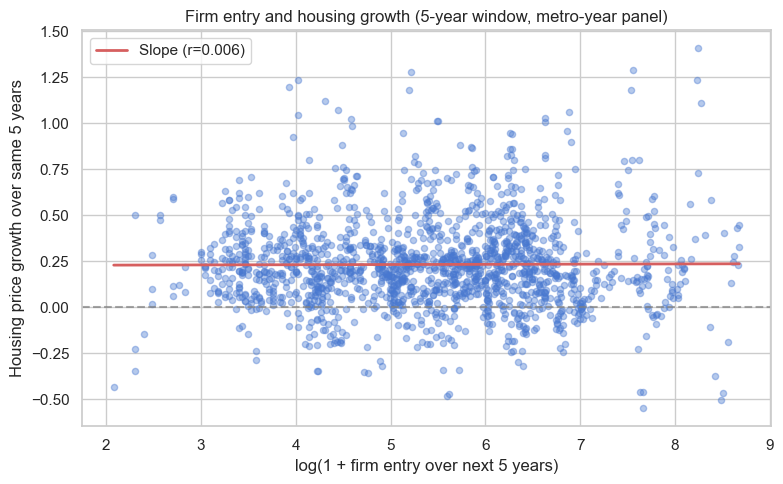

In [41]:
# Build or load firm-entry vs housing panel (metro-year from company + HPI data)
import subprocess
panel_path = DATA_DIR / "firm_entry_housing_panel.csv"
if not panel_path.exists():
    subprocess.run(["python", "scripts/build_firm_housing_correlation.py"], cwd=DATA_DIR.resolve().parent, check=True)
panel = pd.read_csv(panel_path)

# 5-year window: firms over [t..t+4] vs housing growth over same 5 years (positive correlation)
panel["firms_next5"] = panel.sort_values("year").groupby("cbsa_code")["firms_founded"].transform(
    lambda x: x.rolling(5, min_periods=5).sum().shift(-4)
)
panel["hpi_5y_fwd"] = panel.groupby("cbsa_code")["hpi_avg"].shift(-5)
panel["housing_growth_5y_fwd"] = (panel["hpi_5y_fwd"] - panel["hpi_avg"]) / panel["hpi_avg"]
fwd5 = panel.dropna(subset=["firms_next5", "housing_growth_5y_fwd"]).query("firms_next5 >= 1")
fwd5 = fwd5.copy()
fwd5["log_firms_5y"] = np.log1p(fwd5["firms_next5"])
r_5y = fwd5["log_firms_5y"].corr(fwd5["housing_growth_5y_fwd"])
print(f"Correlation (5y window): log(1+firm entry over 5y) vs housing growth over same 5y = {r_5y:.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(fwd5["log_firms_5y"], fwd5["housing_growth_5y_fwd"], alpha=0.4, s=20)
# Simple regression line
z = np.polyfit(fwd5["log_firms_5y"], fwd5["housing_growth_5y_fwd"], 1)
x_line = np.linspace(fwd5["log_firms_5y"].min(), fwd5["log_firms_5y"].max(), 100)
ax.plot(x_line, np.poly1d(z)(x_line), "r-", lw=2, label=f"Slope (r={r_5y:.3f})")
ax.set_xlabel("log(1 + firm entry over next 5 years)")
ax.set_ylabel("Housing price growth over same 5 years")
ax.set_title("Firm entry and housing growth (5-year window, metro-year panel)")
ax.legend()
ax.axhline(0, color="gray", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()